# Autoencoder para Detección de Fraude con Tarjetas de Crédito.

El conjunto de datos que estaremos trabajando representa transacciones de tarjetas de credito anónimas etiquetadas como fraudelantas o genuinas.

The dataset contains transactions made by credit cards in September 2013 by European cardholders.
This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

En este notebook utilizaremos **Autoencoders** para estudiar cómo un modelo puede aprender la estructura subyacente de los datos sin utilizar etiquetas explícitas.  
El objetivo principal es entender el concepto de **representación latente**, el **error de reconstrucción** y cómo este puede emplearse como criterio para la **detección de fraude**. 

Y entonces nos va a interesar ver la Clase 0, es decir donde no se ve los fraudes.

https://fraud-detection-handbook.github.io/fraud-detection-handbook/Chapter_3_GettingStarted/SimulatedDataset.html

# Librerias

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from matplotlib import pyplot as plt

# Cargamos conjunto de datos.

In [2]:
df = pd.read_csv('autoencoders_data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(df.isnull().sum().sort_values(ascending=False))

Time      0
V16       0
Amount    0
V28       0
V27       0
V26       0
V25       0
V24       0
V23       0
V22       0
V21       0
V20       0
V19       0
V18       0
V17       0
V15       0
V1        0
V14       0
V13       0
V12       0
V11       0
V10       0
V9        0
V8        0
V7        0
V6        0
V5        0
V4        0
V3        0
V2        0
Class     0
dtype: int64


In [4]:
print("\nClass distribution:")
print(df['Class'].value_counts(normalize=True).rename('proportion'))


Class distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [5]:
X = df.drop('Class', axis=1).values
y = df['Class'].values

# Preprocesamiento

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División de train / test y selección de datos normales

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train_normal = X_train[y_train == 0]

In [8]:
X_train_normal.shape

(227451, 30)

# Modelo Autoencoder

In [9]:
input_dim = X_train_normal.shape[1]

inputs = tf.keras.Input(shape=(input_dim,))                                 # Esto crea un tensor simbólico, no contiene datos aún, solo define la forma.
encoded = tf.keras.layers.Dense(16, activation='relu')(inputs)
encoded = tf.keras.layers.Dense(8, activation='relu')(encoded)

bottleneck = tf.keras.layers.Dense(4, activation='relu')(encoded)

decoded = tf.keras.layers.Dense(8, activation='relu')(bottleneck)
decoded = tf.keras.layers.Dense(16, activation='relu')(decoded)
outputs = tf.keras.layers.Dense(input_dim, activation='linear')(decoded)

autoencoder = tf.keras.Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')   

2026-01-09 17:24:33.458688: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-01-09 17:24:33.458717: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-01-09 17:24:33.458722: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-01-09 17:24:33.458750: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-09 17:24:33.458763: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Entrenamiento

In [10]:
history = autoencoder.fit(X_train_normal, X_train_normal, epochs = 20, batch_size = 256, validation_split = 0.1, shuffle = True)

Epoch 1/20


2026-01-09 17:24:33.972066: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


800/800 [==============================] - 7s 8ms/step - loss: 0.9180 - val_loss: 1.1521
Epoch 2/20
800/800 [==============================] - 5s 7ms/step - loss: 0.9821 - val_loss: 0.8877
Epoch 3/20
800/800 [==============================] - 6s 7ms/step - loss: 1.1076 - val_loss: 0.9324
Epoch 4/20
800/800 [==============================] - 6s 7ms/step - loss: 0.9990 - val_loss: 0.9226
Epoch 5/20
800/800 [==============================] - 6s 7ms/step - loss: 1.4928 - val_loss: 0.8455
Epoch 6/20
800/800 [==============================] - 5s 7ms/step - loss: 1.0427 - val_loss: 0.8451
Epoch 7/20
800/800 [==============================] - 5s 6ms/step - loss: 1.1880 - val_loss: 0.8968
Epoch 8/20
800/800 [==============================] - 5s 6ms/step - loss: 1.4928 - val_loss: 1.6543
Epoch 9/20
800/800 [==============================] - 5s 6ms/step - loss: 1.1223 - val_loss: 0.9566
Epoch 10/20
800/800 [==============================] - 6s 7ms/step - loss: 1.5076 - val_loss: 0.8550
Epoch 11/2

# Errores de reconstrucción y umbral

7108/7108 [==============================] - 13s 2ms/step


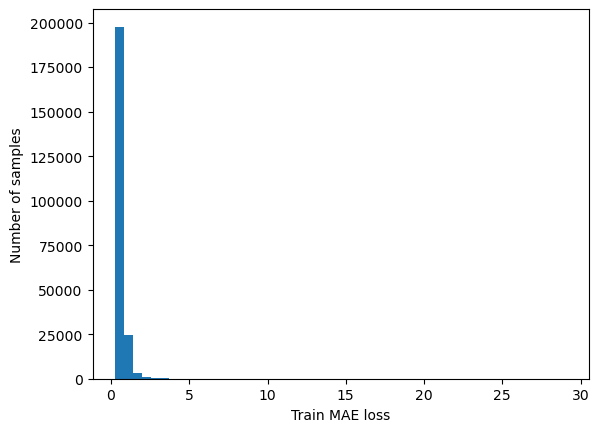

In [11]:
x_train_pred = autoencoder.predict(X_train_normal)
train_mae_loss= np.mean(np.abs(x_train_pred - X_train_normal), axis=1)

plt.hist(train_mae_loss, bins=50)
plt.xlabel("Train MAE loss")
plt.ylabel("Number of samples")
plt.show()

Definimos un umbral para decir que el 99% de los datos normales estén por debajo del umbral, es decir, solo el 1% más raro de los normales serán tratados como sospechosos.

In [12]:
threshold = np.quantile(train_mae_loss, [0.99])[0]
threshold

1.9507514000928534

In [13]:
X_test_pred = autoencoder.predict(X_test)
reconstruction_error = np.mean(np.abs(X_test - X_test_pred), axis=1)

1781/1781 [==============================] - 3s 2ms/step


In [14]:
reconstruction_error

array([7.0734422 , 0.80227482, 0.58653114, ..., 0.82677981, 0.45009026,
       1.44477135])

# Clasificación y métricas 

Hacemos una clasificación binaria basada en umbrales.

si error > threshold → anomalía (1)

si error ≤ threshold → normal (0)

In [15]:
y_pred = (reconstruction_error > threshold).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.10      0.63      0.17        98

    accuracy                           0.99     56962
   macro avg       0.55      0.81      0.58     56962
weighted avg       1.00      0.99      0.99     56962



**Threshold 99%**

Notamos que tenemos una precision muy baja y un recall alto. 

- Clase 0 (normal) - Casi perfecta
- Clase 1 (fraude) - Detectamos muchos fraudes pero con muchos falsos positivos

Eso es esperado cuando usamos un umbral bajo.

In [16]:
print(confusion_matrix(y_test, y_pred))

[[56291   573]
 [   36    62]]


Lectura:

- 573 falsos positivos
- 36 falsos negativos

Buena cobertura de anomalías pero con ruido

In [17]:
y_pred = (reconstruction_error > 0.5).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.21      0.35     56864
           1       0.00      0.99      0.00        98

    accuracy                           0.21     56962
   macro avg       0.50      0.60      0.18     56962
weighted avg       1.00      0.21      0.35     56962



In [18]:
print(confusion_matrix(y_test, y_pred))

[[12046 44818]
 [    1    97]]


**Threshold 50%**

- recall anomalías ≈ 0.99
- precision = 0.00
- accuracy se desploma
